In [1]:
# https://github.com/suryansh-sinha/Conditional-DCGAN/blob/main/cDCGAN.ipynb

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms

# Setting device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
     

In [2]:
# Creating transform for our images
data_transform = transforms.Compose([
    transforms.PILToTensor(),
    transforms.ToDtype(torch.float32, scale=True)
])
     

In [3]:

import os

LR = 0.0002
BETAS = (0.5, 0.999)
EPOCHS = 50
BATCH_SIZE = 128
NUM_WORKERS = 1
LATENT_SIZE = 100
G_EMBED_DIM = 10  # Size of embedding vector for generator
D_EMBED_DIM = 28*28 # Size of embedding vector for discriminator. Don't change this.

In [4]:
# Importing the dataset and creating dataloader.
train_dataset = datasets.MNIST(root='../data/MNIST', train=True, transform=data_transform, download=True)
# train_dataset = datasets.FashionMNIST(root='../data/FMNIST', train=True, transform=data_transform, download=True)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


In [5]:

image, label = next(iter(train_dataloader))
image.shape, label.shape
# print(label)

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

In [6]:

class_names = train_dataset.classes
num_classes = len(class_names)
class_names, num_classes

(['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'],
 10)

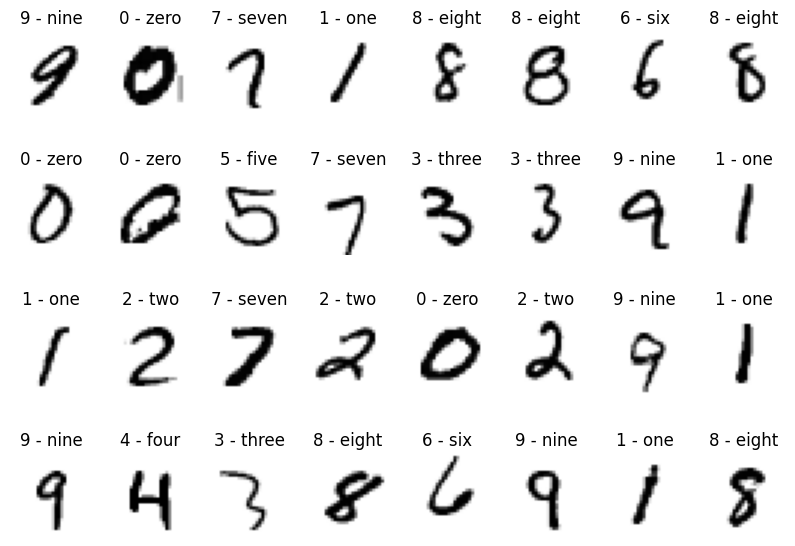

In [7]:
import matplotlib.pyplot as plt

image, label = next(iter(train_dataloader))

plt.figure(figsize=(10,7))
for i in range(32):
 plt.subplot(4, 8, 1 + i)
 img = image[i].permute(1, 2, 0)
 plt.title(f'{class_names[label[i].item()]}')
 plt.imshow(img, cmap='gray_r')
 plt.axis(False)
plt.show()

### Creating the Discriminator

In [8]:
# Creating the discriminator
class Discriminator(nn.Module):

  def __init__(self, in_channels, num_classes, embed_dim):
    super().__init__()

    # We want to create the embedding as an extra image channel and pass it into the model.
    self.label_embed = nn.Embedding(num_classes, embed_dim)

    self.conv_layers = nn.Sequential(
        # Input --> BATCH_SIZE, 2, 28, 28
        nn.Conv2d(in_channels + 1, 64, kernel_size=4, stride=2, padding=1, bias=False),
        nn.LeakyReLU(negative_slope=0.2, inplace=True),
        # Output Feature Maps --> BATCH_SIZE, 64, 14, 14

        nn.Conv2d(64, 64*2, 4, 2, 1, bias=False),
        nn.BatchNorm2d(64*2),
        nn.LeakyReLU(0.2, inplace=True),
        # Output Feature Maps --> BATCH_SIZE, 128, 7, 7

        nn.Conv2d(64*2, 64*4, 4, 2, 1, bias=False),
        nn.BatchNorm2d(64*4),
        nn.LeakyReLU(0.2, inplace=True),
        # Output Feature Maps --> BATCH_SIZE, 256, 3, 3

        nn.Conv2d(64*4, 1, 4, 2, 1, bias=False),
        # nn.BatchNorm2d(256),  Didn't apply BatchNorm2d because it requres atleast (2, 2) tensor to apply normalization.
        # Output Feature Maps --> BATCH_SIZE, 1, 1, 1
    )

    # self.classifier = nn.Sequential(
    #     nn.Flatten(),
    #     nn.Linear(256*1*1, 1)
    # )

  def forward(self, x, label):
    # Passing class label to embedding channel. Want shape as --> [batch_size, 1, 28, 28]
    embed_channel = self.label_embed(label).view(label.size(0), 1, 28, 28)
    # Adding the embedding as additional channel.
    x = torch.cat([x, embed_channel], dim=1)
    output = self.conv_layers(x)
    return output.view(-1, 1).squeeze(1)
     


In [9]:
# # %pip install torch_summary
from torchsummary import summary
discriminator = Discriminator(1, num_classes, D_EMBED_DIM).to(device)
# print(discriminator)
summary(discriminator,torch.zeros(1,1,28,28),torch.ones(1,device=device,dtype=torch.int32))
print(discriminator(torch.torch.zeros(1,1,28,28,device=device),torch.ones(1,device=device,dtype=torch.int32)))

Layer (type:depth-idx)                   Output Shape              Param #
├─Embedding: 1-1                         [-1, 784]                 7,840
├─Sequential: 1-2                        [-1, 1, 1, 1]             --
|    └─Conv2d: 2-1                       [-1, 64, 14, 14]          2,048
|    └─LeakyReLU: 2-2                    [-1, 64, 14, 14]          --
|    └─Conv2d: 2-3                       [-1, 128, 7, 7]           131,072
|    └─BatchNorm2d: 2-4                  [-1, 128, 7, 7]           256
|    └─LeakyReLU: 2-5                    [-1, 128, 7, 7]           --
|    └─Conv2d: 2-6                       [-1, 256, 3, 3]           524,288
|    └─BatchNorm2d: 2-7                  [-1, 256, 3, 3]           512
|    └─LeakyReLU: 2-8                    [-1, 256, 3, 3]           --
|    └─Conv2d: 2-9                       [-1, 1, 1, 1]             4,096
Total params: 670,112
Trainable params: 670,112
Non-trainable params: 0
Total mult-adds (M): 12.22
Input size (MB): 0.00
Forward/backw

### Creating the Generator 
For transpose convolutions on square tensors, the formula is 

H_out =(H_in - 1) * stride - 2 * padding + dilation * (kernel_size-1) + output_padding + 1 

dilation is 1 by default, output padding is 0 by default 

H_out = (H_in-1) * stride + (kernel_size-1) - 2 * padding + 1 

In [10]:
def get_noise(batch_size: int, z_dim: int, device: torch.device = device):
  return torch.randn(batch_size, z_dim, 1, 1).to(device)

class Generator(nn.Module):

  def __init__(self, z_dim, num_classes, embed_dim):
    super().__init__()

    self.embed_layer = nn.Embedding(num_classes, embed_dim) # 10 inputs to embed_dim outputs.

    self.trans_conv_layers = nn.Sequential(
        # Input is latent dimension vector of size --> z_dim + num_classes, 1, 1
        nn.ConvTranspose2d(z_dim + embed_dim, 64*8, 4, 2, 1),
        nn.BatchNorm2d(64*8),
        nn.ReLU(inplace=True),
        # Output Size = 512, 2, 2

        nn.ConvTranspose2d(64*8, 64*4, 4, 2, 1),
        nn.BatchNorm2d(64*4),
        nn.ReLU(True),
        # Output Size = 256, 4, 4

        nn.ConvTranspose2d(64*4, 64*2, 4, 2, 1),
        nn.BatchNorm2d(64*2),
        nn.ReLU(True),
        # Output Size = 128, 8, 8

        nn.ConvTranspose2d(64*2, 64, 4, 2, 1),
        nn.BatchNorm2d(64),
        nn.ReLU(True),
        # Output Size = 64, 16, 16

        nn.ConvTranspose2d(64, 1, 4, 2, 3),
        nn.Tanh()
        # Output Size = 1, 28, 28
    )

  # We send the label as 2nd input to generate images targeting that specific label.
  def forward(self, noise, label):
    embed_tensor = self.embed_layer(label)  # Shape --> 32, 10. Want --> 32, 10, 1, 1.
    embed_tensor = embed_tensor.unsqueeze(2).unsqueeze(3)  # Add dimensions to match noise
    noise = torch.cat((noise, embed_tensor), dim=1)  # Concatenate along the channel dimension
    return self.trans_conv_layers(noise)
     


In [11]:
generator = Generator(LATENT_SIZE, num_classes, G_EMBED_DIM).to(device)
summary(generator,torch.zeros(1,LATENT_SIZE,1,1),torch.ones(1,device=device,dtype=torch.int32))
output=generator(torch.zeros(1,LATENT_SIZE,1,1,device=device),torch.ones(1,device=device,dtype=torch.int32))
print(output.shape)

Layer (type:depth-idx)                   Output Shape              Param #
├─Embedding: 1-1                         [-1, 10]                  100
├─Sequential: 1-2                        [-1, 1, 28, 28]           --
|    └─ConvTranspose2d: 2-1              [-1, 512, 2, 2]           901,632
|    └─BatchNorm2d: 2-2                  [-1, 512, 2, 2]           1,024
|    └─ReLU: 2-3                         [-1, 512, 2, 2]           --
|    └─ConvTranspose2d: 2-4              [-1, 256, 4, 4]           2,097,408
|    └─BatchNorm2d: 2-5                  [-1, 256, 4, 4]           512
|    └─ReLU: 2-6                         [-1, 256, 4, 4]           --
|    └─ConvTranspose2d: 2-7              [-1, 128, 8, 8]           524,416
|    └─BatchNorm2d: 2-8                  [-1, 128, 8, 8]           256
|    └─ReLU: 2-9                         [-1, 128, 8, 8]           --
|    └─ConvTranspose2d: 2-10             [-1, 64, 16, 16]          131,136
|    └─BatchNorm2d: 2-11                 [-1, 64, 16, 16]

### Write training and testing loop

In [12]:
# Training the discriminator.
def train_discriminator(discriminator: nn.Module,
                        generator: nn.Module,
                        d_optim: torch.optim.Optimizer,
                        real_images: torch.Tensor,
                        labels: torch.Tensor,
                        latent_size: int,
                        loss_fn: nn.Module,
                        device: torch.device = device):

  # Setting appropriate modes for models.
  # discriminator.train()
  # generator.eval()

  current_batch_size = len(labels)

  # Make predictions
  real_preds = discriminator(real_images, labels)
  real_targets = torch.ones_like(real_preds)
  real_loss = loss_fn(real_preds, real_targets)

  # Generate fake images
  latent = get_noise(current_batch_size, latent_size)
  fake_images = generator(latent, labels)

  # Pass fake images through discriminator
  # 在原始GAN论文中，生成器试图最小化的损失确实包含了log(1-D(G(z)))这项，
  # 但在实践中，为了更容易优化，生成器通常会直接尝试最大化D(G(z))，
  # 即使用-log(D(G(z)))作为损失函数的一部分。这种做法在训练过程中更为稳定。
  fake_preds = discriminator(fake_images, labels)
  fake_targets = torch.zeros_like(fake_preds)
  fake_loss = loss_fn(fake_preds, fake_targets)

  ############################
  # Update D network: maximize log(D(x)) + log(1 - D(G(z)))
  ###########################
  # Update discriminator weights
  loss = real_loss + fake_loss
  d_optim.zero_grad()
  loss.backward()
  d_optim.step()

  return loss.item()
     

In [13]:
# Training the generator.
def train_generator(discriminator: nn.Module,
                    generator: nn.Module,
                    g_optim: torch.optim.Optimizer,
                    labels: torch.Tensor,
                    latent_size: int,
                    loss_fn: nn.Module,
                    device: torch.device = device):

  # Setting appropriate states for models.
  # discriminator.eval()
  # generator.train()

  current_batch_size = len(labels)

  # Generate fake images.
  latent = get_noise(current_batch_size, latent_size)
  fake_images = generator(latent, labels)

  # Pass the images to discriminator.
  preds = discriminator(fake_images, labels)
  target = torch.ones_like(preds)  # 1 because we want discriminator to think this is real.

  # Calculate the loss.
  loss = loss_fn(preds, target)

  # Update weights
  g_optim.zero_grad()
  loss.backward()
  g_optim.step()

  return loss.item()
     


In [14]:

# Creating the generator and discriminator.
generator = Generator(LATENT_SIZE, num_classes, G_EMBED_DIM).to(device)
discriminator = Discriminator(1, num_classes, D_EMBED_DIM).to(device)

In [15]:
from torchvision.utils import make_grid
from tqdm import tqdm
def train(epochs, lr, betas, device: torch.device = device):

  d_losses = []
  g_losses = []

  # Creating optimizers and loss function.
  g_optim = torch.optim.Adam(generator.parameters(),
                            lr=LR, betas=betas)
  d_optim = torch.optim.Adam(discriminator.parameters(),
                            lr=LR, betas=betas)

  loss_fn = nn.BCEWithLogitsLoss()
  # loss_fn = nn.BCELoss()
  for epoch in range(epochs):

    d_loss, g_loss = 0, 0

    for batch, (real_images, labels) in enumerate(tqdm(train_dataloader)):

      # Moving data to target device
      real_images = real_images.to(device)
      labels = labels.to(device)

      # Train discriminator
      d_loss += train_discriminator(discriminator, generator, d_optim, real_images, labels, LATENT_SIZE, loss_fn, device)

      # Train generator
      g_loss += train_generator(discriminator, generator, g_optim, labels, LATENT_SIZE, loss_fn, device)

    # Calculating the average loss per batch
    d_loss /= len(train_dataloader)
    g_loss /= len(train_dataloader)

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    # Print info
    print("Epoch: [{}/{}] | Discriminator Loss: {:.4f} | Generator Loss: {:.4f}".format(
        epoch+1, epochs, d_loss, g_loss
    ))

  return d_losses, g_losses


In [27]:

d_losses, g_losses = train(EPOCHS, LR, BETAS)

100%|██████████| 469/469 [00:14<00:00, 31.57it/s]


Epoch: [1/50] | Discriminator Loss: 0.6030 | Generator Loss: 2.9993


100%|██████████| 469/469 [00:14<00:00, 32.12it/s]


Epoch: [2/50] | Discriminator Loss: 0.5948 | Generator Loss: 2.6375


100%|██████████| 469/469 [00:14<00:00, 31.47it/s]


...

100%|██████████| 469/469 [00:14<00:00, 31.94it/s]


Epoch: [32/50] | Discriminator Loss: 0.0255 | Generator Loss: 5.3166


100%|██████████| 469/469 [00:14<00:00, 31.55it/s]


Epoch: [33/50] | Discriminator Loss: 0.0109 | Generator Loss: 6.1857


 41%|████      | 193/469 [00:06<00:08, 32.49it/s]

In [1]:

plt.plot(d_losses, '-')
plt.plot(g_losses, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

NameError: name 'plt' is not defined

In [2]:
class_names

NameError: name 'class_names' is not defined

In [3]:

def generate_image(generator, latent_size, class_index):
  noise = get_noise(1, latent_size)
  label = torch.Tensor([class_index]).type(torch.IntTensor).to(device)
  output = generator(noise, label).detach().to('cpu')
  output = output.squeeze(dim=0)
  output = output.permute(1, 2, 0)
  plt.imshow(output, cmap='gray')

generate_image(generator, LATENT_SIZE, 2)


NameError: name 'generator' is not defined